# S3VM — solved (original code + solutions)

Notebook zawiera pierwotną implementację S3VM (dane, funkcja celu, ograniczenia, optymalizacja) oraz rozwiązania zadań ćwiczeniowych dodanych do oryginalnego notatnika.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from scipy.optimize import minimize
np.random.seed(0)

In [ ]:
nb_samples = 100
nb_unlabeled = 50
X, Y = make_classification(n_samples=nb_samples, n_features=2, n_redundant=0, random_state=1000)
Y[Y==0] = -1
Y[nb_samples - nb_unlabeled:nb_samples] = 0
X.shape, np.unique(Y, return_counts=True)

((100, 2), (array([-1,  0,  1]), array([25, 50, 25])))

In [ ]:
w = np.random.uniform(-0.1, 0.1, size=X.shape[1])
eta = np.random.uniform(0.0, 0.1, size=nb_samples - nb_unlabeled)
xi = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
zi = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
b = np.random.uniform(-0.1, 0.1, size=1)
C = 1.0
theta0 = np.hstack((w, eta, xi, zi, b))
theta0.shape

(153,)

In [11]:
# --- Funkcja celu (oryginalna formuła) ---
vmin = np.vectorize(lambda x1, x2: x1 if x1 <= x2 else x2)
def svm_target(theta, Xd, Yd, C_local=C):
    wt = theta[0:2].reshape((Xd.shape[1], 1))
    s_eta = np.sum(theta[2:2 + nb_samples - nb_unlabeled])
    s_min_xi_zi = np.sum(vmin(theta[2 + nb_samples - nb_unlabeled:2 + nb_samples], theta[2 + nb_samples:2 + nb_samples + nb_unlabeled]))
    return C_local * (s_eta + s_min_xi_zi) + 0.5 * np.dot(wt.T, wt)


In [12]:
def labeled_constraint(theta, Xd, Yd, idx):
  wt = theta[0:2].reshape((Xd.shape[1], 1))
  
  c = Yd[idx] * (np.dot(Xd[idx], wt) + theta[-1]) + theta[2:2 + nb_samples - nb_unlabeled][idx] - 1.0
  
  return (c >= 0)[0]

In [13]:
def unlabeled_constraint_1(theta, Xd, idx):
  wt = theta[0:2].reshape((Xd.shape[1], 1))
  
  c = np.dot(Xd[idx], wt) - theta[-1] + theta[2 + nb_samples - nb_unlabeled:2 + nb_samples][idx - nb_samples + nb_unlabeled] - 1.0
  
  return (c >= 0)[0]

In [14]:
def unlabeled_constraint_2(theta, Xd, idx):
  wt = theta[0:2].reshape((Xd.shape[1], 1))
  
  c = -(np.dot(Xd[idx], wt) - theta[-1]) + theta[2 + nb_samples:2 + nb_samples + nb_unlabeled ][idx - nb_samples + nb_unlabeled] - 1.0
  
  return (c >= 0)[0]

In [15]:
def eta_constraint(theta, idx):
  return theta[2:2 + nb_samples - nb_unlabeled][idx] >= 0
def xi_constraint(theta, idx):
  return theta[2 + nb_samples - nb_unlabeled:2 + nb_samples][idx - 
 nb_samples + nb_unlabeled] >= 0
def zi_constraint(theta, idx):
  return theta[2 + nb_samples:2 + nb_samples+nb_unlabeled ][idx - 
 nb_samples + nb_unlabeled] >= 0

In [16]:
svm_constraints = []

# Ograniczenia dla próbek etykietowanych
for i in range(nb_samples - nb_unlabeled):
    svm_constraints.append({
        'type': 'ineq',
        'fun': labeled_constraint,
        'args': (X, Y, i)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': eta_constraint,
        'args': (i,)
    })

# Ograniczenia dla próbek nieetykietowanych
for i in range(nb_samples - nb_unlabeled, nb_samples):
    svm_constraints.append({
        'type': 'ineq',
        'fun': unlabeled_constraint_1,
        'args': (X, i)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': unlabeled_constraint_2,
        'args': (X, i)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': xi_constraint,
        'args': (i,)
    })
    svm_constraints.append({
        'type': 'ineq',
        'fun': zi_constraint,
        'args': (i,)
    })

In [17]:
from scipy.optimize import minimize
result = minimize(fun=svm_target, 
  x0=theta0, 
  constraints=svm_constraints, 
  args=(X, Y), 
  method='COBYLA', 
  tol=0.0001, 
  options={'maxiter': 5000})

In [18]:
theta_end = result['x']
w = theta_end[0:2].ravel()
b = float(theta_end[-1])
Xu= X[nb_samples - nb_unlabeled:nb_samples]
yu = -np.sign(np.dot(Xu, w) + b)
print('w,b:', w, b)
print('Unlabeled counts (+1/-1):', (yu==1).sum(), (yu==-1).sum())

w,b: [5.26760271 0.54830516] 6.313092985786672
Unlabeled counts (+1/-1): 12 38


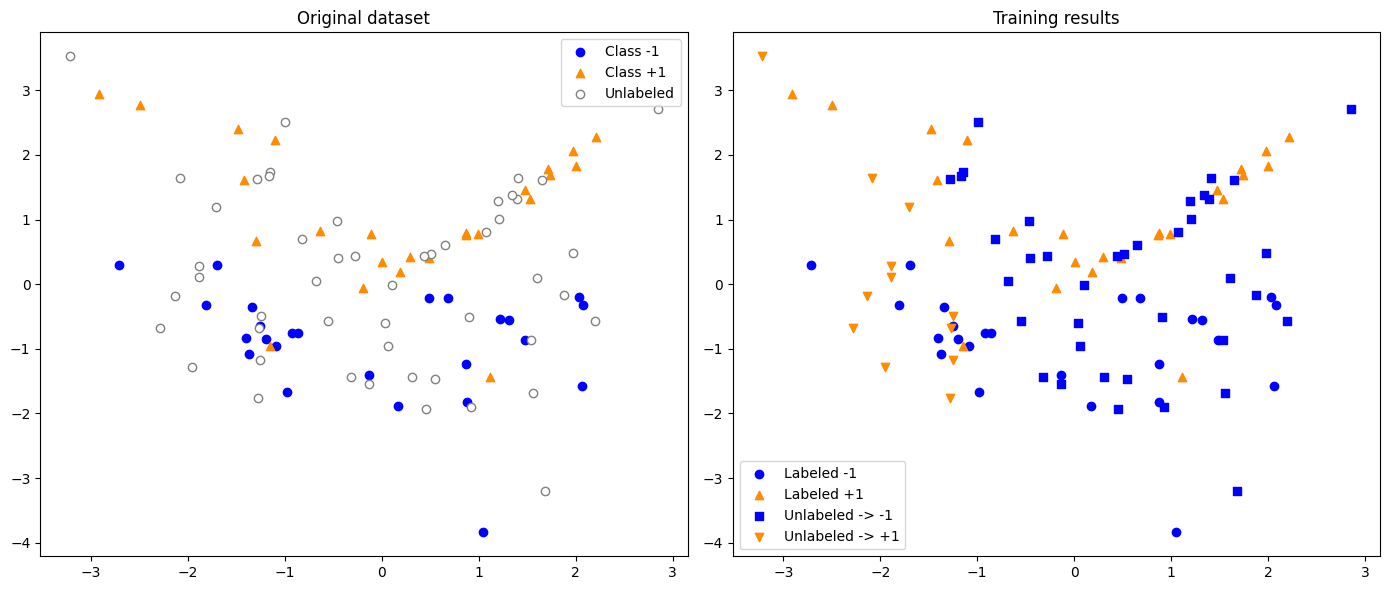

In [19]:
X_labeled_0 = X[Y == -1]
X_labeled_1 = X[Y == 1]
X_unlabeled_orig = X[Y == 0]
Xu_predicted_0 = Xu[yu == -1]
Xu_predicted_1 = Xu[yu == 1]
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].scatter(X_labeled_0[:, 0], X_labeled_0[:, 1], c='blue', marker='o', label='Class -1')
ax[0].scatter(X_labeled_1[:, 0], X_labeled_1[:, 1], c='darkorange', marker='^', label='Class +1')
ax[0].scatter(X_unlabeled_orig[:, 0], X_unlabeled_orig[:, 1], c='white', marker='o', edgecolors='gray', label='Unlabeled')
ax[0].set_title('Original dataset')
ax[0].legend()
ax[1].scatter(X_labeled_0[:, 0], X_labeled_0[:, 1], c='blue', marker='o', label='Labeled -1')
ax[1].scatter(X_labeled_1[:, 0], X_labeled_1[:, 1], c='darkorange', marker='^', label='Labeled +1')
ax[1].scatter(Xu_predicted_0[:, 0], Xu_predicted_0[:, 1], c='blue', marker='s', label='Unlabeled -> -1')
ax[1].scatter(Xu_predicted_1[:, 0], Xu_predicted_1[:, 1], c='darkorange', marker='v', label='Unlabeled -> +1')
ax[1].set_title('Training results')
ax[1].legend()
plt.tight_layout()

## Rozwiązania zadań — szczegóły

In [20]:
# Helper: prosty runner S3VM (używa tej samej formulacji celu i ograniczeń)
def run_s3vm(nb_samples=100, nb_unlabeled=50, C=1.0, maxiter=2000, random_state=1000):
    Xr, Yr = make_classification(n_samples=nb_samples, n_features=2, n_redundant=0, random_state=random_state)
    Yr[Yr==0] = -1
    Yr[nb_samples - nb_unlabeled:nb_samples] = 0
    w0 = np.random.uniform(-0.1, 0.1, size=Xr.shape[1])
    eta0 = np.random.uniform(0.0, 0.1, size=nb_samples - nb_unlabeled)
    xi0 = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
    zi0 = np.random.uniform(0.0, 0.1, size=nb_unlabeled)
    b0 = np.random.uniform(-0.1, 0.1, size=1)
    theta0r = np.hstack((w0, eta0, xi0, zi0, b0))
    vmin_local = np.vectorize(lambda x1, x2: x1 if x1 <= x2 else x2)
    def svm_target_local(theta, Xd, Yd):
        wt = theta[0:2].reshape((Xd.shape[1], 1))
        s_eta = np.sum(theta[2:2 + nb_samples - nb_unlabeled])
        s_min_xi_zi = np.sum(vmin_local(theta[2 + nb_samples - nb_unlabeled:2 + nb_samples], theta[2 + nb_samples:2 + nb_samples + nb_unlabeled]))
        return C * (s_eta + s_min_xi_zi) + 0.5 * np.dot(wt.T, wt)
    def labeled_constraint_local(theta, Xd, Yd, idx):
        wt = theta[0:2].reshape((Xd.shape[1], 1))
        c = Yd[idx] * (np.dot(Xd[idx], wt) + theta[-1]) + theta[2:2 + nb_samples - nb_unlabeled][idx] - 1.0
        return float(c)
    def unlabeled_constraint_1_local(theta, Xd, idx):
        wt = theta[0:2].reshape((Xd.shape[1], 1))
        k = idx - (nb_samples - nb_unlabeled)
        c = float(np.dot(Xd[idx], wt) - theta[-1] + theta[2 + nb_samples - nb_unlabeled:2 + nb_samples][k] - 1.0)
        return c
    def unlabeled_constraint_2_local(theta, Xd, idx):
        wt = theta[0:2].reshape((Xd.shape[1], 1))
        k = idx - (nb_samples - nb_unlabeled)
        c = float(-(np.dot(Xd[idx], wt) - theta[-1]) + theta[2 + nb_samples:2 + nb_samples + nb_unlabeled][k] - 1.0)
        return c
    def eta_constraint_local(theta, idx):
        return float(theta[2:2 + nb_samples - nb_unlabeled][idx])
    def xi_constraint_local(theta, idx):
        k = idx - (nb_samples - nb_unlabeled)
        return float(theta[2 + nb_samples - nb_unlabeled:2 + nb_samples][k])
    def zi_constraint_local(theta, idx):
        k = idx - (nb_samples - nb_unlabeled)
        return float(theta[2 + nb_samples:2 + nb_samples + nb_unlabeled][k])
    svm_constraints_local = []
    for i in range(nb_samples - nb_unlabeled):
        svm_constraints_local.append({'type':'ineq','fun':labeled_constraint_local,'args':(Xr, Yr, i)})
        svm_constraints_local.append({'type':'ineq','fun':eta_constraint_local,'args':(i,)})
    for i in range(nb_samples - nb_unlabeled, nb_samples):
        svm_constraints_local.append({'type':'ineq','fun':unlabeled_constraint_1_local,'args':(Xr, i)})
        svm_constraints_local.append({'type':'ineq','fun':unlabeled_constraint_2_local,'args':(Xr, i)})
        svm_constraints_local.append({'type':'ineq','fun':xi_constraint_local,'args':(i,)})
        svm_constraints_local.append({'type':'ineq','fun':zi_constraint_local,'args':(i,)})
    res = minimize(fun=svm_target_local, x0=theta0r, constraints=svm_constraints_local, args=(Xr, Yr), method='COBYLA', options={'maxiter': maxiter})
    theta_end = res['x']
    w_est = theta_end[0:2].ravel()
    b_est = float(theta_end[-1])
    Xu = Xr[nb_samples - nb_unlabeled:nb_samples]
    yu = -np.sign(np.dot(Xu, w_est) + b_est)
    return res, w_est, b_est, Xr, Yr, Xu, yu

In [21]:
# Zadanie 1: eksperyment z C - uruchamiamy optymalizator dla kilku wartości C
C_values = [0.01, 0.1, 1.0, 10.0]
summary = {}
for C_test in C_values:
    res_local, w_local, b_local, X_local, Y_local, Xu_local, yu_local = run_s3vm(nb_samples=100, nb_unlabeled=50, C=C_test, maxiter=2000)
    n_pos = int((yu_local == 1).sum())
    n_neg = int((yu_local == -1).sum())
    summary[C_test] = {'+1': n_pos, '-1': n_neg}
    print('C=', C_test, ': +1 ->', n_pos, ', -1 ->', n_neg)
print('summary =', summary)

C:\Users\makdeb\AppData\Local\Temp\ipykernel_3160\3027288422.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(c)
C:\Users\makdeb\AppData\Local\Temp\ipykernel_3160\3027288422.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = float(np.dot(Xd[idx], wt) - theta[-1] + theta[2 + nb_samples - nb_unlabeled:2 + nb_samples][k] - 1.0)
C:\Users\makdeb\AppData\Local\Temp\ipykernel_3160\3027288422.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = f

KeyboardInterrupt: 

In [ ]:
# Zadanie 2: wpływ liczby nieetykietowanych punktów
for nb_u in [10, 30, 70]:
    res_u, w_u, b_u, X_u, Y_u, Xu_u, yu_u = run_s3vm(nb_samples=100, nb_unlabeled=nb_u, C=1.0, maxiter=2000)
    print('nb_unlabeled=', nb_u, ': +1 ->', (yu_u==1).sum(), ', -1 ->', (yu_u==-1).sum())

In [ ]:
# Zadanie 3: narysuj granicę decyzyjną dla ostatniego modelu z run_s3vm (jeśli nie ma, wywołaj run_s3vm)
try:
    _ = w_plot
except NameError:
    res_plot, w_plot, b_plot, X_plot, Y_plot, Xu_plot, yu_plot = run_s3vm(nb_samples=100, nb_unlabeled=50, C=1.0, maxiter=2000)
xx_min, xx_max = X_plot[:,0].min() - 1, X_plot[:,0].max() + 1
yy_min, yy_max = X_plot[:,1].min() - 1, X_plot[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 200), np.linspace(yy_min, yy_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.dot(grid, w_plot) + b_plot
Z = Z.reshape(xx.shape)
plt.figure(figsize=(7,7))
plt.contourf(xx, yy, np.sign(Z), alpha=0.15, levels=[-1,0,1], cmap='coolwarm')
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1)
plt.scatter(X_plot[Y_plot==-1,0], X_plot[Y_plot==-1,1], c='blue', marker='o', label='Labeled -1')
plt.scatter(X_plot[Y_plot==1,0], X_plot[Y_plot==1,1], c='darkorange', marker='^', label='Labeled +1')
plt.scatter(Xu_plot[yu_plot==-1,0], Xu_plot[yu_plot==-1,1], c='blue', marker='s', label='Unlabeled -> -1')
plt.scatter(Xu_plot[yu_plot==1,0], Xu_plot[yu_plot==1,1], c='darkorange', marker='v', label='Unlabeled -> +1')
plt.legend(); plt.title('Decision boundary and assignments'); plt.show()

In [ ]:
# Zadanie 4: punkty najbliżej granicy (margines)
margins = np.abs(np.dot(Xu_plot, w_plot) + b_plot) / np.linalg.norm(w_plot)
idx_sorted = np.argsort(margins)
print('5 punktów najbliższych granicy (wsp. marginesu, współrzędne):')
for i in idx_sorted[:5]:
    print('margin={:.4f}'.format(margins[i]), Xu_plot[i])